# 🔗 Correlation — Measuring How Two Numeric Variables Move Together
### Stage 6: Pearson & Spearman Correlation  |  ⏱️ ~40-minute session

---

**Recap:** so far we've compared groups (Stages 3–4) and counted categories (Stage 5). Today's question is different — we're no longer comparing groups, we're asking about **relationships between two numeric variables measured on the same subjects**.

### The one question correlation answers
> *"When one variable goes up, does the other tend to go up too, go down, or do its own thing?"*

Just like Stages 3–4 had a parametric/non-parametric pair, correlation has the exact same split:

| Test | Measures | Assumption | Non-parametric? |
|---|---|---|---|
| **Pearson's r** | Strength of a **linear** relationship | Roughly normal data, linear relationship | ❌ Parametric |
| **Spearman's ρ (rho)** | Strength of a **monotonic** relationship (based on ranks) | None — works on ranks | ✅ Non-parametric |

### Session map (suggested pacing)

| Time | Topic |
|---|---|
| 0:00 – 0:14 | Pearson Correlation |
| 0:14 – 0:22 | Checking assumptions: why Pearson can lie to you |
| 0:22 – 0:32 | Spearman's Rank Correlation |
| 0:32 – 0:37 | Correlation matrices & the correlation ≠ causation warning |
| 0:37 – 0:40 | Recap |

We'll use `tips` and `penguins` — plus one crafted example designed to break Pearson on purpose, so the need for Spearman becomes obvious rather than abstract.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (7, 4)
sns.set_style("whitegrid")
np.random.seed(42)

tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins").dropna()

print(tips.shape, penguins.shape)
tips.head()


(244, 7) (333, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1️⃣ Pearson Correlation — "How strong (and linear) is the relationship?"

### Theory

Pearson's correlation coefficient, **r**, measures the strength and direction of a **linear** relationship between two continuous variables.

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

- **Range:** −1 to +1
- **r = +1** → perfect positive linear relationship
- **r = −1** → perfect negative linear relationship
- **r = 0** → no *linear* relationship (there could still be a strong non-linear one!)

**Rough interpretation guide (Cohen's convention):**

| \|r\| | Strength |
|---|---|
| 0.10 – 0.29 | Weak |
| 0.30 – 0.49 | Moderate |
| 0.50 – 1.00 | Strong |

- **H₀:** True population correlation = 0 (no linear relationship)
- **H₁:** True population correlation ≠ 0

### Scenario
Does `total_bill` relate to `tip` amount? (Common sense says yes — bigger bills, bigger tips — let's quantify exactly how strong that relationship is.)


In [2]:
r, p_value = stats.pearsonr(tips['total_bill'], tips['tip'])

print(f"Pearson's r: {r:.4f}")
print(f"p-value: {p_value:.2e}")

if p_value < 0.05:
    print(f"Verdict: Reject H0 -> Significant linear relationship (strength: {'strong' if abs(r)>0.5 else 'moderate' if abs(r)>0.3 else 'weak'})")
else:
    print("Verdict: Fail to reject H0 -> No significant linear relationship detected")


Pearson's r: 0.6757
p-value: 6.69e-34
Verdict: Reject H0 -> Significant linear relationship (strength: strong)


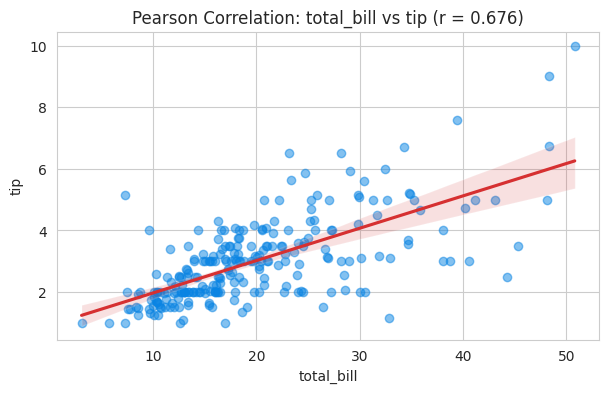

In [3]:
fig, ax = plt.subplots()
sns.regplot(data=tips, x='total_bill', y='tip', ax=ax,
            scatter_kws={'alpha': 0.5, 'color': '#0984e3'}, line_kws={'color': '#d63031'})
ax.set_title(f"Pearson Correlation: total_bill vs tip (r = {r:.3f})")
plt.show()


**What r=0.68 tells us:** there's a moderately strong, positive linear relationship — the fitted red line captures the trend reasonably well, and points cluster fairly close around it.

### 🎯 60-second challenge
Compute Pearson's r between `bill_length_mm` and `flipper_length_mm` in the `penguins` dataset. Is the relationship stronger or weaker than total_bill vs tip?


In [4]:
r2, p2 = stats.pearsonr(penguins['bill_length_mm'], penguins['flipper_length_mm'])
print(f"r = {r2:.4f}, p = {p2:.2e}")


r = 0.6531, p = 7.21e-42


## 2️⃣ Why Pearson Can Lie To You — Checking Assumptions

Pearson's r assumes:
1. **Linearity** — the relationship is a straight line, not a curve
2. **Roughly normal data** for both variables (or at least no extreme outliers)
3. **Homoscedasticity** — the spread of y doesn't change systematically as x increases

### The classic warning example: Anscombe-style non-linear relationship

Let's construct a variable that has a **strong, obvious, perfectly predictable** relationship with x — but it's curved, not linear. Watch what Pearson does.


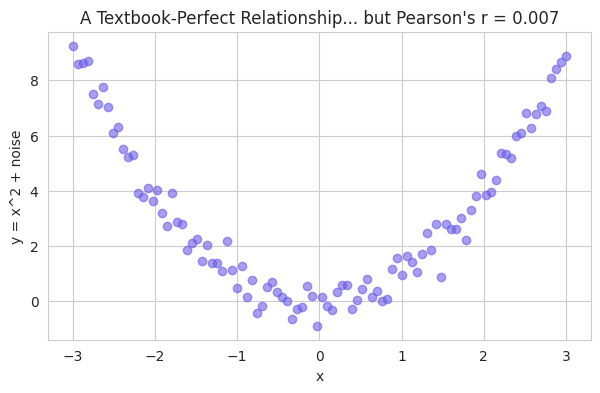

Pearson's r: 0.0072  (p=0.9435)

Notice: r is close to ZERO, even though y is COMPLETELY determined by x!
Pearson only detects LINEAR patterns -- it is blind to this perfect curved relationship.


In [5]:
x = np.linspace(-3, 3, 100)
y_curved = x**2 + np.random.normal(0, 0.5, 100)  # perfect U-shape relationship, plus a little noise

r_curved, p_curved = stats.pearsonr(x, y_curved)

fig, ax = plt.subplots()
ax.scatter(x, y_curved, alpha=0.6, color='#6c5ce7')
ax.set_title(f"A Textbook-Perfect Relationship... but Pearson's r = {r_curved:.3f}")
ax.set_xlabel("x")
ax.set_ylabel("y = x^2 + noise")
plt.show()

print(f"Pearson's r: {r_curved:.4f}  (p={p_curved:.4f})")
print("\nNotice: r is close to ZERO, even though y is COMPLETELY determined by x!")
print("Pearson only detects LINEAR patterns -- it is blind to this perfect curved relationship.")


**The lesson:** always plot your data before trusting a correlation coefficient. A low r doesn't mean "no relationship" — it means "no *linear* relationship." This exact blind spot is one of the reasons Spearman's rank correlation exists — while Spearman still won't catch this particular U-shape (it's not monotonic either), it *will* catch monotonic-but-curved relationships, which Pearson also misses. Let's see that next.


## 3️⃣ Spearman's Rank Correlation — "Is there a consistent (monotonic) trend, even if it's not a straight line?"

### Theory

Spearman's ρ (rho) is the non-parametric sibling of Pearson. Instead of using raw values, it:
1. **Ranks** both variables separately.
2. Computes Pearson's correlation formula **on the ranks** instead of the raw values.

This makes it sensitive to **any monotonic relationship** — meaning "as x increases, y consistently increases (or consistently decreases)" — even if the *rate* of increase isn't constant (i.e., not a straight line).

$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

where $d_i$ = difference between the ranks of each paired observation.

- **H₀:** No monotonic relationship (ρ = 0)
- **H₁:** A monotonic relationship exists

**Bonus advantage:** because it uses ranks, Spearman is much more **robust to outliers** than Pearson — one extreme value can barely move the ranks, but it can massively swing a raw-value correlation.

### Scenario A: A perfect monotonic-but-curved relationship (exponential growth)


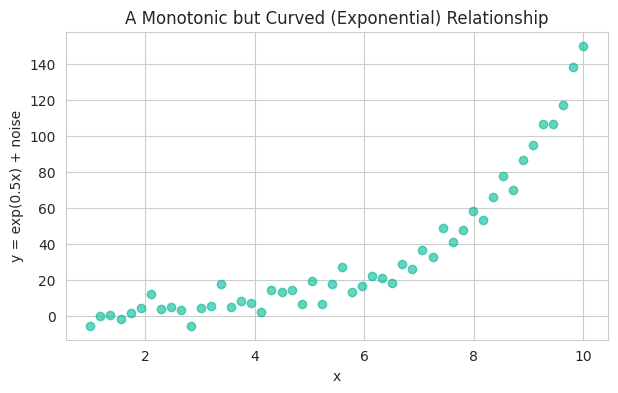

Pearson's r:   0.8688  (p=2.93e-16)  <- underestimates the relationship's strength
Spearman's rho: 0.9593  (p=5.27e-28)  <- correctly detects the strong monotonic trend


In [6]:
x2 = np.linspace(1, 10, 50)
y_exp = np.exp(x2 * 0.5) + np.random.normal(0, 5, 50)  # monotonically increasing, but NOT a straight line

r_pearson, p_pearson = stats.pearsonr(x2, y_exp)
rho_spearman, p_spearman = stats.spearmanr(x2, y_exp)

fig, ax = plt.subplots()
ax.scatter(x2, y_exp, alpha=0.6, color='#00b894')
ax.set_title("A Monotonic but Curved (Exponential) Relationship")
ax.set_xlabel("x")
ax.set_ylabel("y = exp(0.5x) + noise")
plt.show()

print(f"Pearson's r:   {r_pearson:.4f}  (p={p_pearson:.2e})  <- underestimates the relationship's strength")
print(f"Spearman's rho: {rho_spearman:.4f}  (p={p_spearman:.2e})  <- correctly detects the strong monotonic trend")


**The takeaway:** Spearman's ρ is noticeably higher here because the relationship, while curved, is perfectly *consistent* — every increase in x brings an increase in y. Pearson penalizes this for not being a straight line; Spearman doesn't care about the shape, only the consistent direction.

### Scenario B: Outlier robustness — Pearson vs Spearman head-to-head


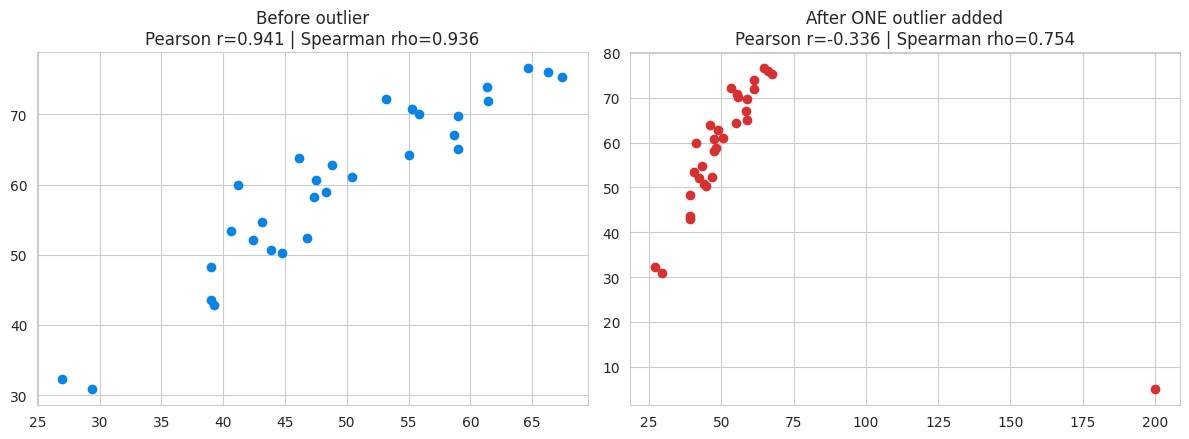

Pearson's r changed by:   1.277
Spearman's rho changed by: 0.181


In [7]:
np.random.seed(1)
x3 = np.random.normal(50, 10, 30)
y3 = x3 * 1.2 + np.random.normal(0, 5, 30)  # clean linear relationship

# Now inject ONE extreme outlier
x3_outlier = np.append(x3, 200)
y3_outlier = np.append(y3, 5)  # a bizarre, extreme low value paired with a huge x

r_before, _ = stats.pearsonr(x3, y3)
r_after, _ = stats.pearsonr(x3_outlier, y3_outlier)
rho_before, _ = stats.spearmanr(x3, y3)
rho_after, _ = stats.spearmanr(x3_outlier, y3_outlier)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(x3, y3, color='#0984e3')
axes[0].set_title(f"Before outlier\nPearson r={r_before:.3f} | Spearman rho={rho_before:.3f}")

axes[1].scatter(x3_outlier, y3_outlier, color='#d63031')
axes[1].set_title(f"After ONE outlier added\nPearson r={r_after:.3f} | Spearman rho={rho_after:.3f}")

plt.tight_layout()
plt.show()

print(f"Pearson's r changed by:   {abs(r_after - r_before):.3f}")
print(f"Spearman's rho changed by: {abs(rho_after - rho_before):.3f}")


**This is the whole pitch for Spearman in one plot:** a single bizarre data point drags Pearson's r drastically (sometimes even flipping its sign), while Spearman — since it only cares about rank order — barely notices. If your data has outliers or you're not confident about normality, Spearman is the safer default.

### Practical: Spearman on real data


In [8]:
rho, p_value = stats.spearmanr(tips['total_bill'], tips['tip'])
print(f"Spearman's rho (total_bill vs tip): {rho:.4f}, p={p_value:.2e}")
print(f"(Compare to Pearson's r we found earlier: {r:.4f} -- very similar, since this relationship is fairly linear and clean)")


Spearman's rho (total_bill vs tip): 0.6790, p=2.50e-34
(Compare to Pearson's r we found earlier: 0.6757 -- very similar, since this relationship is fairly linear and clean)


### 🎯 60-second challenge
Compute both Pearson's r and Spearman's ρ between `body_mass_g` and `flipper_length_mm` in `penguins`. Are they close to each other? What would a big gap between the two values suggest about the shape of the relationship?


In [9]:
r_p, p_p = stats.pearsonr(penguins['body_mass_g'], penguins['flipper_length_mm'])
rho_s, p_s = stats.spearmanr(penguins['body_mass_g'], penguins['flipper_length_mm'])
print(f"Pearson r = {r_p:.4f} | Spearman rho = {rho_s:.4f}")


Pearson r = 0.8730 | Spearman rho = 0.8404


## 4️⃣ Correlation Matrices & The Golden Warning

### Practical: correlating multiple variables at once
When you have several numeric variables, a **correlation matrix heatmap** is the fastest way to scan for relationships worth investigating further.


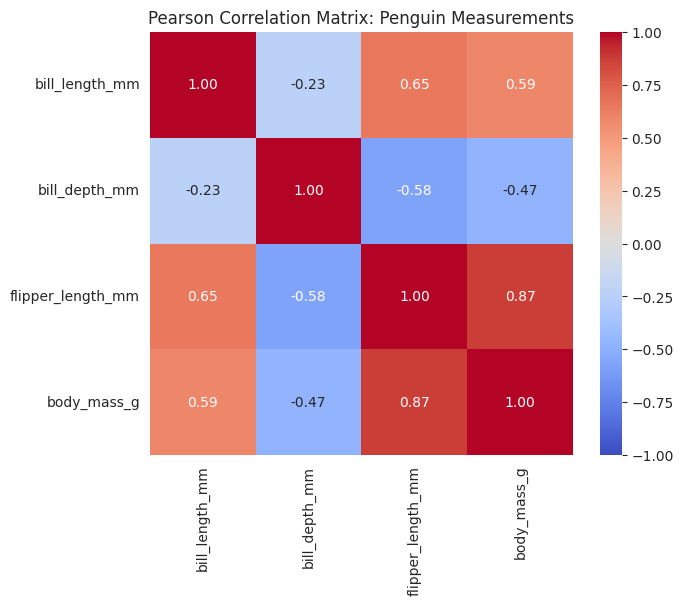

In [10]:
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
corr_matrix = penguins[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Pearson Correlation Matrix: Penguin Measurements")
plt.show()


**Notice the pattern:** `flipper_length_mm` and `body_mass_g` are strongly positively correlated (bigger flippers, heavier birds — makes biological sense). But `bill_depth_mm` correlates *negatively* with the others — a reminder to always sanity-check what a heatmap is telling you (this actually reflects species differences mixed together, not a single unified trend — something you'd catch immediately by adding a `hue='species'` to a scatter plot).

### ⚠️ Correlation is NOT Causation — the warning every trainer must repeat

A strong correlation between X and Y could mean:
1. X causes Y
2. Y causes X
3. A **third variable (confounder)** causes both
4. It's pure coincidence (especially with small samples or many variables tested at once)

**Classic joke example:** ice cream sales and drowning deaths are strongly correlated — not because ice cream causes drowning, but because **both are driven by hot summer weather** (a confounding variable). Always ask *"what else could explain this pattern?"* before assuming a causal story.


## 📋 Cheat Sheet — Stage 6 Recap

| | Pearson's r | Spearman's ρ |
|---|---|---|
| **Detects** | Linear relationships | Monotonic relationships (linear or curved) |
| **Uses** | Raw values | Ranks |
| **Assumption** | Roughly normal, linear | None (non-parametric) |
| **Outlier sensitivity** | High | Low (robust) |
| **When to use** | Data is clean, roughly normal, relationship looks like a straight line | Data has outliers, is skewed, ordinal, or the relationship looks curved-but-consistent |

### The workflow
1. **Always plot a scatter plot first.** Never trust a correlation number you haven't visualized.
2. Check if the pattern looks linear → Pearson. Curved-but-consistent, has outliers, or ordinal data → Spearman.
3. Remember: correlation (of any kind) never proves causation on its own.

**Next up:** Stage 7 — moving from *measuring* a relationship to actually **modeling and predicting** with it: Linear Regression.
